В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: varvarakopyl
Your Kaggle Key: ··········


100%|██████████| 637k/637k [00:00<00:00, 1.40MB/s]



Extracting archive ./bank-customer-churn-prediction-dlu-course-c-5/bank-customer-churn-prediction-dlu-course-c-5.zip to ./bank-customer-churn-prediction-dlu-course-c-5
F1 score Training: 0.70%
AUROC for Training: 0.91


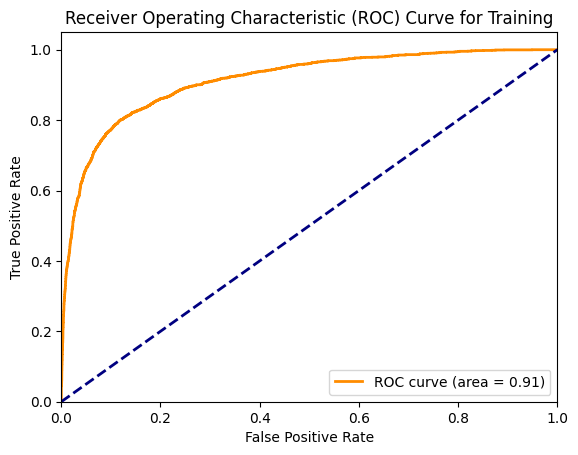

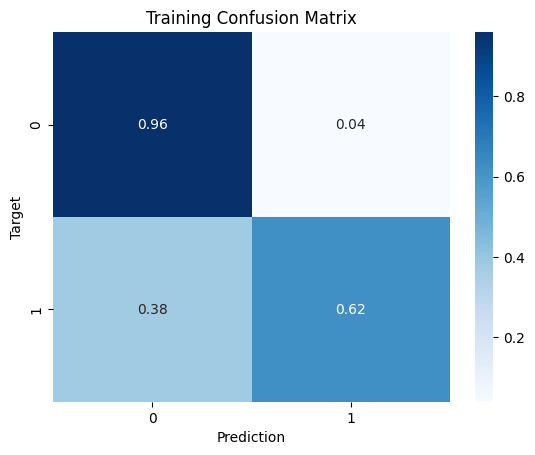

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


F1 score Validation: 0.63%
AUROC for Validation: 0.85


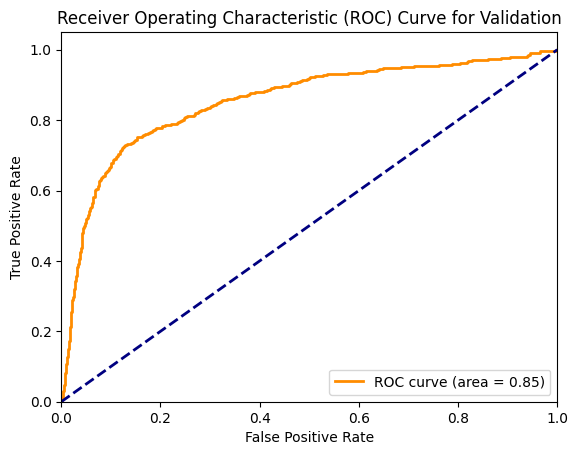

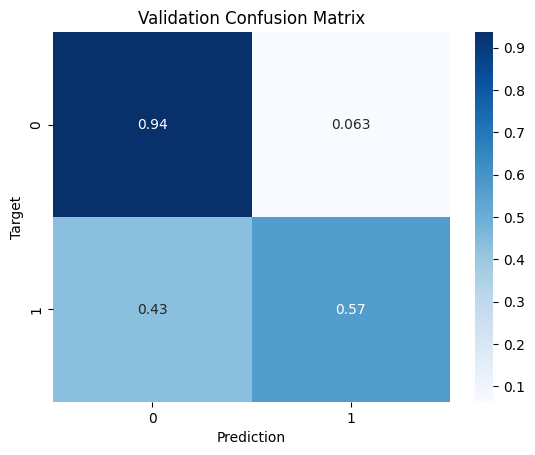

In [2]:
!pip install opendatasets --upgrade --quiet
import opendatasets as od
import os
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Завантаження даних з Kaggle
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-5/data$0'
od.download(dataset_url)
data_dir = './bank-customer-churn-prediction-dlu-course-c-5'
test_csv = data_dir + '/test.csv'
train_csv = data_dir + '/train.csv'
sample_submission_csv = data_dir + '/sample_submission.csv'


# Вичитка тренувальних даних (перша колонка використовується як індекси)
raw_df = pd.read_csv(train_csv, index_col=0)


# Розділення тренувальних даних на тренувальні та валідаційні
# stratify зберігає розподіл класів 0 та 1 однаковий в обох наборах, аби уникнути перекосу
train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df["Exited"])


# Розділення наборів на X та Y
input_cols = list(train_df.columns)[1:-1] # x - колонки до достанньої НЕвключно
target_col = 'Exited' # y - остання колонка - цільова

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()


# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist() # np.number - узагальнений тип для числових даних
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()


# Створюємо трансформери для числових і категоріальних колонок
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore'))
]) #drop='if_binary' для бінарних колонок створює одну колонку і рандомно присвоює 0 та 1, а не так, як я вказувала конкретно


# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols), #'passthrough' означає, що числові колонки поки пропустити без змін (так як масштабуємо їх після кодування категоріальних разом)
        ('cat', categorical_transformer, categorical_cols)
    ])


# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуємо модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(solver='liblinear'))
])


# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)


# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)

    # F1-score
    f1_score_ = f1_score(targets, preds, pos_label=1)
    print(f"F1 score {name}: {f1_score_:.2f}%")

    # AUROC
    y_pred_proba = model_pipeline.predict_proba(inputs)[:, 1]
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {roc_auc:.2f}')
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
    plt.legend(loc="lower right")
    plt.show()

    # Confusion matrix
    cf = confusion_matrix(targets, preds, normalize='true') #normalize - дані нормалізовані, тобто частки вірно/хибно прогнозованих від усіх реальних позитивних/негативних
    plt.figure()
    sns.heatmap(cf, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()

    return preds


# Оцінюємо модель на трен. і вал. даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Training')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')


# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, "log_reg_pipeline.joblib")
model_2 = joblib.load('log_reg_pipeline.joblib')


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

F1 score Polynomial Training: 0.77%
AUROC for Polynomial Training: 0.95


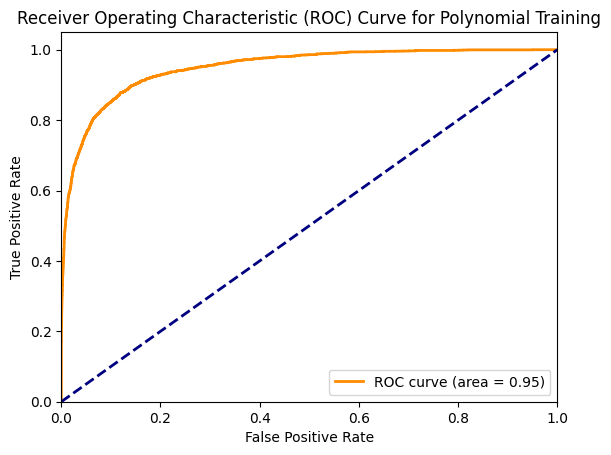

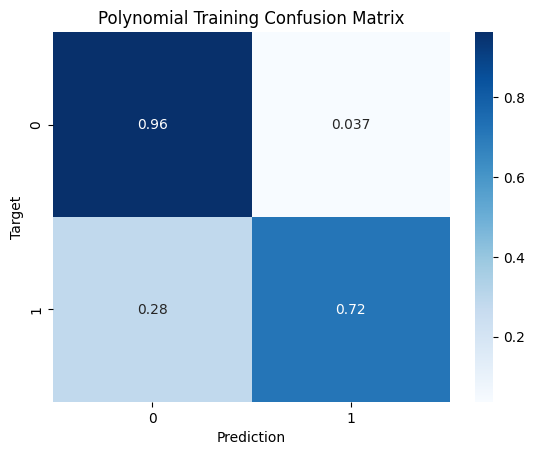

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


F1 score Polynomial Validation: 0.69%
AUROC for Polynomial Validation: 0.90


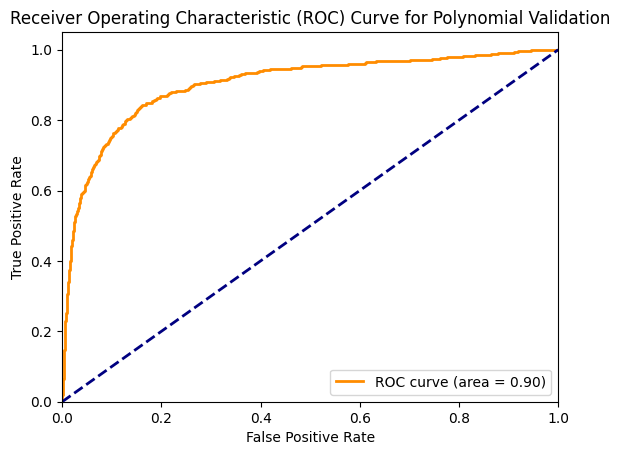

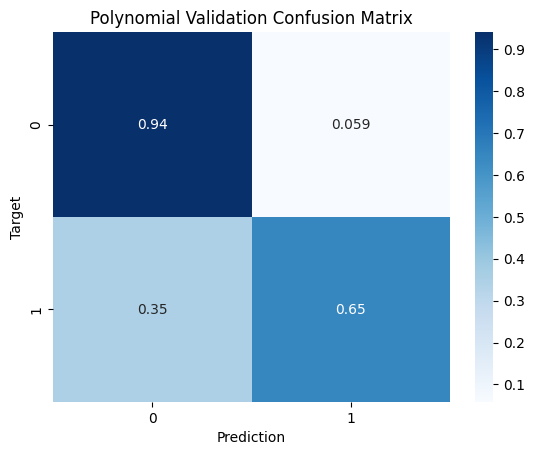

In [8]:
from sklearn.preprocessing import PolynomialFeatures

# Новий трансформер для числових колонок
numeric_transformer_poly = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)) #include_bias=False - щоб не створювати зайву постійну колонку з одиниць: у логістичної регресії вже є власний вільний коефіцієнт
])

# Новий препроцесор
preprocessor_poly = ColumnTransformer(transformers=[
    ('num', numeric_transformer_poly, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Новий пайплайн
model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Навчання
model_pipeline_poly.fit(train_inputs, train_targets)

# Оцінювання
poly_train_preds = predict_and_plot(
    model_pipeline_poly,
    train_inputs,
    train_targets,
    'Polynomial Training'
)

poly_val_preds = predict_and_plot(
    model_pipeline_poly,
    val_inputs,
    val_targets,
    'Polynomial Validation'
)

**ВИСНОВОК**

Після додавання поліноміальних ознак другого степеня модель показала F1-score 0.77 на тренувальному та 0.69 на валідаційному наборі. Значення AUROC становлять відповідно 0.95 та 0.90.

Результати на тренувальному наборі є дещо вищими, ніж на валідаційному, тому спостерігаються ознаки невеликого перенавчання. Водночас метрики на валідаційному наборі залишаються достатньо високими, особливо AUROC = 0.90, тому модель загалом добре узагальнює закономірності на нових даних. Ознак underfit не спостерігається.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

F1 score Polynomial Training: 0.78%
AUROC for Polynomial Training: 0.96


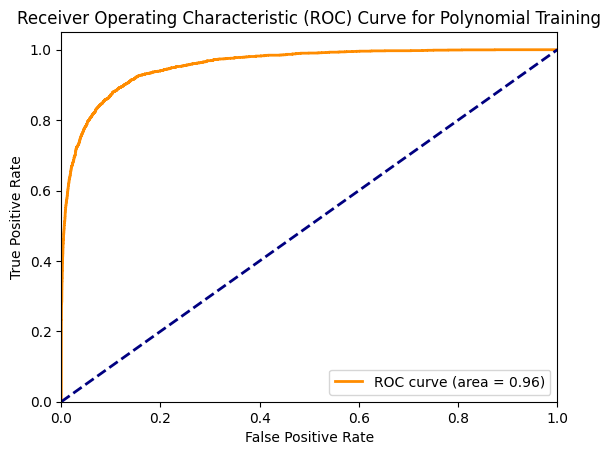

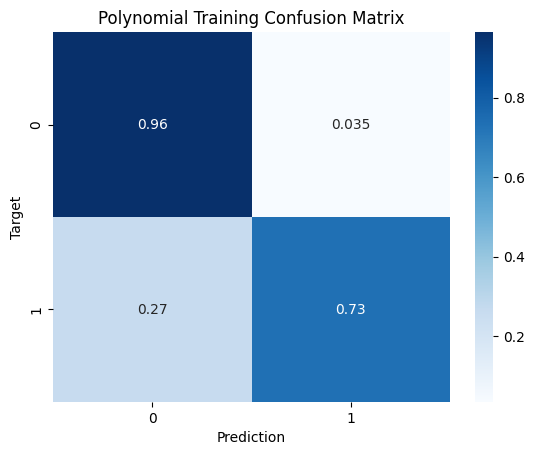

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


F1 score Polynomial Validation: 0.71%
AUROC for Polynomial Validation: 0.91


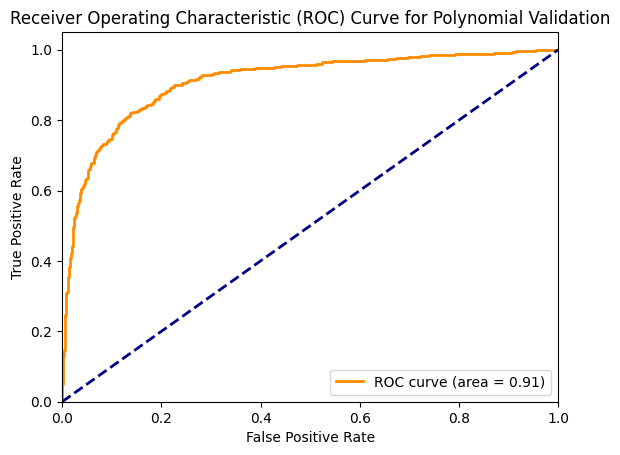

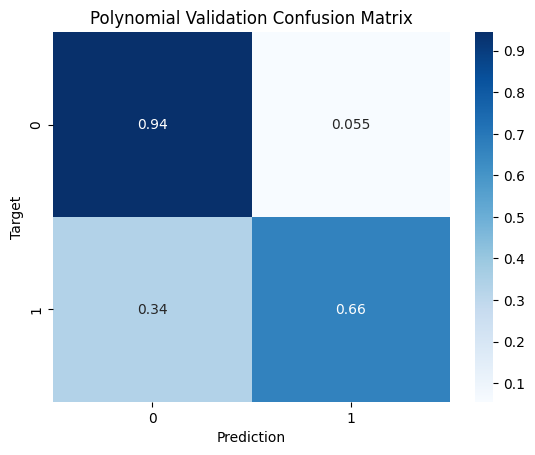

In [7]:
from sklearn.preprocessing import PolynomialFeatures

# Новий трансформер для числових колонок
numeric_transformer_poly4 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=4, include_bias=False)) #include_bias=False - щоб не створювати зайву постійну колонку з одиниць: у логістичної регресії вже є власний вільний коефіцієнт
])

# Новий препроцесор
preprocessor_poly4 = ColumnTransformer(transformers=[
    ('num', numeric_transformer_poly4, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Новий пайплайн
model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Навчання
model_pipeline_poly4.fit(train_inputs, train_targets)

# Оцінювання
poly4_train_preds = predict_and_plot(
    model_pipeline_poly,
    train_inputs,
    train_targets,
    'Polynomial Training'
)

poly4_val_preds = predict_and_plot(
    model_pipeline_poly,
    val_inputs,
    val_targets,
    'Polynomial Validation'
)

***Для сабмішену в змагання***

Створимо копію моделі, але натренуємо на всіх тренувальних даних (розділення на train та val більше не потрбіно, так модель обрали - валідаційні дані виконали свою ф-цію)

In [10]:
from sklearn.base import clone

final_model = clone(model_pipeline_poly4)

full_inputs = raw_df[input_cols]
full_targets = raw_df[target_col]

final_model.fit(full_inputs, full_targets)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('poly',
                                                                   PolynomialFeatures(degree=4,
                                                                                      include_bias=False))]),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Surname', 'Geography',
                                                   'Gender'])])),
                ('scaler', StandardScaler()),
                ('classifier', LogisticRegression(solver='liblinear'))])

In [16]:
test_raw_df = pd.read_csv(test_csv)

test_inputs = test_raw_df[input_cols]

test_prob = final_model.predict_proba(test_inputs)[:, 1]

test_raw_df["Exited"] = test_prob

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [17]:
sample_submission = pd.read_csv(sample_submission_csv)

In [18]:
sample_submission["Exited"] = sample_submission["id"].map(test_raw_df.set_index("id")["Exited"])

In [19]:
sample_submission.to_csv("submission_poly4.csv", index=False)

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Читання даних
from google.colab import drive
drive.mount('/content/drive')
regression_df = pd.read_csv('drive/MyDrive/regression_data.csv')

display(regression_df.head())
print(regression_df.columns)

# X та y
X = regression_df.iloc[:, :-1]
y = regression_df.iloc[:, -1]

print('Ознаки:', X.columns.tolist())
print('Ціль:', y.name)

# Поділ на train і test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Пайплайн
poly5_pipeline = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Навчання
poly5_pipeline.fit(X_train, y_train)

# Прогнози
train_predictions = poly5_pipeline.predict(X_train)
test_predictions = poly5_pipeline.predict(X_test)

# Оцінювання
def evaluate_regression(targets, predictions, name=''):
    r2 = r2_score(targets, predictions)
    mae = mean_absolute_error(targets, predictions)
    rmse = np.sqrt(mean_squared_error(targets, predictions))

    print(f'\n{name}:')
    print(f'R²:   {r2:.4f}')
    print(f'MAE:  {mae:.4f}')
    print(f'RMSE: {rmse:.4f}')

evaluate_regression(y_train, train_predictions, 'Training')
evaluate_regression(y_test, test_predictions,'Test')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


Index(['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5',
       'target'],
      dtype='object')
Ознаки: ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']
Ціль: target

Training:
R²:   1.0000
MAE:  0.0000
RMSE: 0.0000

Test:
R²:   0.9311
MAE:  8.0778
RMSE: 12.6767


**ВИСНОВОК**

Модель поліноміальної регресії 5-ого степеня показала ідеальні результати на тренувальному наборі: `R-squared` = 1, `MAE` = 0 та `RMSE` = 0. Це означає, що модель повністю підлаштувалася під тренувальні дані. Є прямі ознаки перенавчання.

Однак на тестовому наборі `R-squared` = 0.9311, тобто модель пояснює приблизно 93.1% варіації цільової змінної. Значення `MAE` = 8.0 та `RMSE` = 12.6 свідчать, що на нових даних уже присутні помилки прогнозування, причому окремі похибки є досить великими.

Отже, модель має високу прогнозну якість і загалом добре узагальнює дані (враховуючи високу оцінку якості на тесті), однак ідеальні метрики на train та гірші результати на test вказують на перенавчання. Причиною може бути велика кількість ознак, створених поліномом до п’ятого степеня. Для зменшення перенавчання доцільно застосувати регуляризацію або знизити степінь поліноміальних ознак.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [24]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Функція створює пайплайн:
# поліноміальні ознаки degree=20 -> масштабування -> модель
def create_poly20_pipeline(model):
    return Pipeline(steps=[
        ('poly', PolynomialFeatures(degree=20, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

# Регуляризовані моделі
models = {
    'Lasso': create_poly20_pipeline(Lasso(alpha=1.0, max_iter=100000)),
    'Ridge': create_poly20_pipeline(Ridge(alpha=1.0)),
    'ElasticNet': create_poly20_pipeline(ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=100000))
    }

# Функція для розрахунку метрик
def calculate_metrics(targets, predictions):
  return {
      'R²': r2_score(targets, predictions),
      'MAE': mean_absolute_error(targets, predictions),
      'RMSE': np.sqrt(mean_squared_error(targets, predictions))
    }
results = []
trained_models = {}

# Навчаємо Lasso, Ridge та ElasticNet
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    train_predictions = pipeline.predict(X_train)
    test_predictions = pipeline.predict(X_test)

    train_metrics = calculate_metrics(y_train, train_predictions)

    test_metrics = calculate_metrics(y_test, test_predictions)

    coefficients = pipeline.named_steps['model'].coef_

    results.append({
        'Model': name,

        'Train R²': train_metrics['R²'],
        'Test R²': test_metrics['R²'],

        'Train RMSE': train_metrics['RMSE'],
        'Test RMSE': test_metrics['RMSE'],

        'All coefficients': len(coefficients)
    })

# Додаємо результати LinearRegression degree=5 із завдання 4
linear_train_predictions = poly5_pipeline.predict(X_train)
linear_test_predictions = poly5_pipeline.predict(X_test)

linear_train_metrics = calculate_metrics(y_train, linear_train_predictions)

linear_test_metrics = calculate_metrics(y_test, linear_test_predictions)

results.append({
    'Model': 'LinearRegression degree 5',

    'Train R²': linear_train_metrics['R²'],
    'Test R²': linear_test_metrics['R²'],

    'Train RMSE': linear_train_metrics['RMSE'],
    'Test RMSE': linear_test_metrics['RMSE'],

    'All coefficients': np.nan
})

# Загальна таблиця
comparison_df = pd.DataFrame(results)

# Ставимо попередню LinearRegression першою
comparison_df = comparison_df.iloc[[3, 0, 1, 2]].reset_index(drop=True)

display(comparison_df.round(4))

,Model,Train R²,Test R²,Train RMSE,Test RMSE,All coefficients
0,LinearRegression degree 5,1.0000,0.9311,0.0000,12.6767,NaN
1,Lasso,0.9989,0.9992,1.4794,1.3921,53129.0
2,Ridge,0.9994,0.6688,1.0537,27.7976,53129.0
3,ElasticNet,0.9255,0.8177,12.0443,20.6240,53129.0


**ВИСНОВОК**

Серед перевірених моделей найкращу якість і генералізацію показала модель Lasso. На тренувальному наборі її `R-squared` = 0.99, а на тестовому — 0.9992. Значення `RMSE` також є близькими: 1.47 на train та 1.39 на test. Отже, модель однаково добре працює на тренувальних і нових даних та не демонструє помітного перенавчання.

`LinearRegression` (5-го степеня) без регуляризації має ідеальні метрики на train, але помітно гірші на test, що вказує на перенавчання.

`Ridge` також майже ідеально описує тренувальні дані, проте має найгірший тестовий результат, тому генералізує погано.

`ElasticNet` показала нижчі метрики на обох наборах.

Імовірною причиною переваги `Lasso` є L1-регуляризація. Після генерації 53 129 поліноміальних ознак багато з них виявилися зайвими або корельованими. Lasso може прирівнювати коефіцієнти таких ознак до нуля, зменшуючи складність моделі та залишаючи найбільш корисні ознаки. **Тому за поточних параметрів `Lasso` є найкращою моделлю.**